In [1]:
#import giggle_my_version as giggle
import numpy as np 
import matplotlib.pyplot as plt

import math
#from scipy import ndimage as ndimage
#import disk_ecc_spiral as disk
#import disk_ecc as kevindisk
#import disk_ecc_spiral_pp as proto
#from astropy import units as u
#from astropy.constants import G, sigma_sb, k_B, m_p
from astropy.io import fits
import bettermoments as bm
import matplotlib.gridspec as gridspec


from astropy.io import fits
from astropy.wcs import WCS
from matplotlib.patches import Ellipse

import astropy.units as u
from astropy.wcs.utils import proj_plane_pixel_scales
import cmcrameri.cm as cmc
from mpl_toolkits.axes_grid1.anchored_artists import AnchoredSizeBar

import cmocean
#from scipy.interpolate import LinearNDInterpolator as interpnd

In [5]:
path = '49Ceti_resid_map_4-18.fits'
data, velax = bm.load_cube(path)
rms = bm.estimate_RMS(data=data, N=1)
m0 = bm.collapse_zeroth(velax=velax, data=data, rms=rms)
bm.save_to_FITS(moments=m0, method='zeroth', path=path)

In [6]:
path = '49Ceti_model_map_4-18.fits'
data, velax = bm.load_cube(path)
rms = bm.estimate_RMS(data=data, N=1)
m0 = bm.collapse_zeroth(velax=velax, data=data, rms=rms)
bm.save_to_FITS(moments=m0, method='zeroth', path=path)

In [7]:
def wcs_extent(image, wcs):
    nx, ny = image.shape
    cx, cy = nx / 2.0, ny / 2.0
    ctr = wcs.pixel_to_world(cx, cy)
    ra_ctr = ctr.ra
    dec_ctr = ctr.dec
    left = wcs.pixel_to_world(0, cy).ra
    right = wcs.pixel_to_world(nx - 1, cy).ra
    bot = wcs.pixel_to_world(cx, 0).dec
    top = wcs.pixel_to_world(cx, ny - 1).dec
    ra_scale = np.cos(dec_ctr.rad) * 3600.0
    return [
        (left - ra_ctr).deg * ra_scale,
        (right - ra_ctr).deg * ra_scale,
        (bot - dec_ctr).deg * 3600.0,
        (top - dec_ctr).deg * 3600.0,
    ]

In [8]:
parallax = 17.4725e-3
dist = 1/parallax

scalelength = 100*u.au.to(u.parsec)
theta = scalelength/dist
theta_rad = theta*u.rad.to(u.deg)

In [23]:
plt.rcParams["font.size"] = 16    

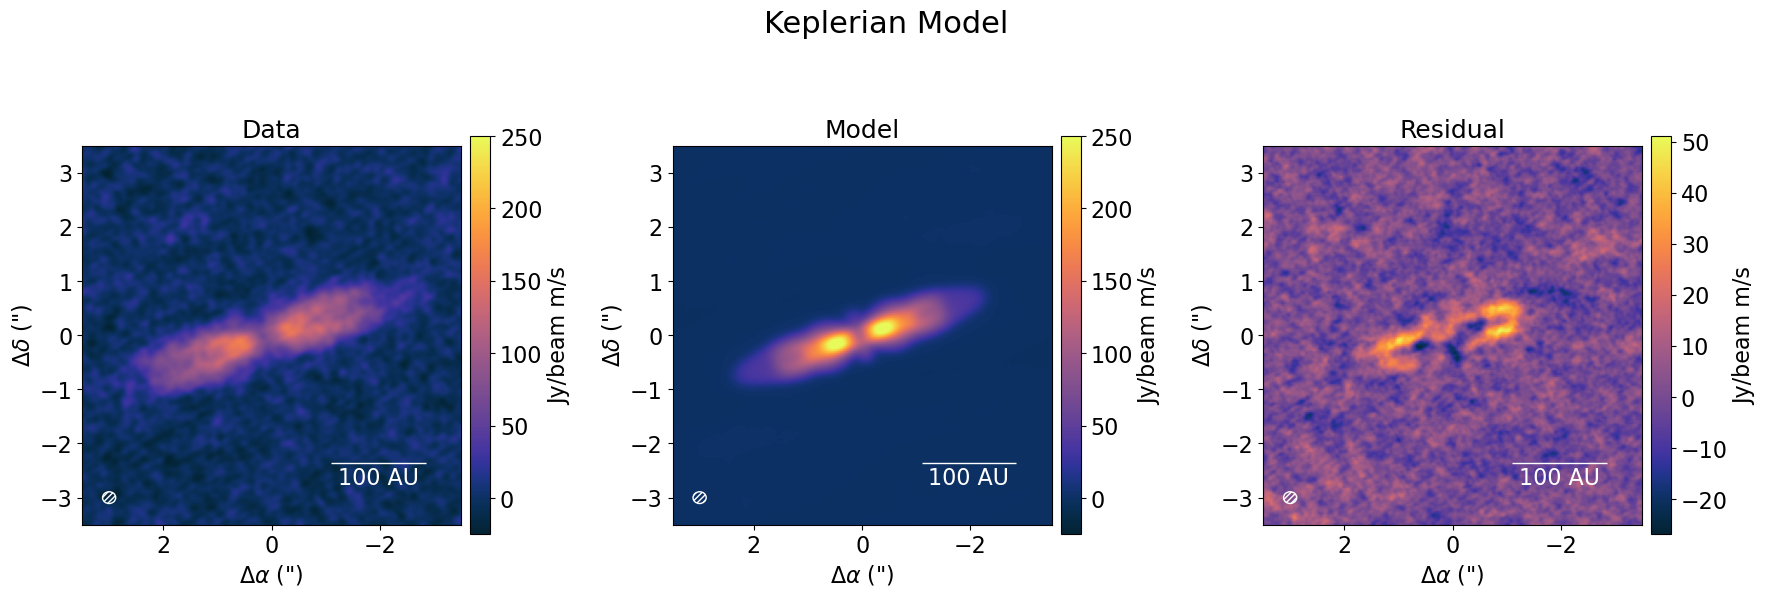

In [ ]:

# Load images and WCS (reuse from earlier cells if possible)
data_fits  = fits.open('12CO_LSRK_cleanimage_M0.fits')
model_fits = fits.open('49Ceti_model_map_4-18_M0.fits')
resid_fits = fits.open('49Ceti_resid_map_4-18_M0.fits')

data_image  = data_fits['PRIMARY'].data
model_image = model_fits['PRIMARY'].data
resid_image = resid_fits['PRIMARY'].data

wcs = WCS(data_fits['PRIMARY'].header)  # Use data WCS for all (assuming shared)
header = data_fits['PRIMARY'].header

# Compute extent using the 2-arg function (from Cell 6)
extent_data = wcs_extent(data_image, wcs)
# Note: Using extent_data for all to keep offsets consistent; adjust if needed

# Beam parameters from header (in degrees)
bmaj_deg = header['BMAJ']  # Major axis
bmin_deg = header['BMIN']  # Minor axis
bpa_deg  = header['BPA']   # Position angle

# Convert to arcseconds (for plotting in offset coords)
bmaj_arcsec = bmaj_deg * 3600.0
bmin_arcsec = bmin_deg * 3600.0
bpa_arcsec  = bpa_deg  # Angle remains the same

# Plot 3 panels
fig = plt.figure(figsize=(18, 6))
fig.suptitle("Keplerian Model", fontsize=22, y=1)
gs = gridspec.GridSpec(nrows=1, ncols=3, figure=fig)

panels = [
    (data_image, 'Data', -25, 250),
    (model_image, 'Model', -25, 250),
    (resid_image, 'Residual', None, None),  # Auto-scale for residuals
]

for i, (img, title, vmin, vmax) in enumerate(panels):
    ax = fig.add_subplot(gs[0, i])
    ax.set_aspect('equal')
    im = plt.imshow(img, cmap=cmocean.cm.thermal, origin="lower", extent=extent_data, vmin=vmin, vmax=vmax)
    ax.set_xlim(3.5, -3.5)
    ax.set_ylim(-3.5, 3.5)
    if i!=0:
        cbar = plt.colorbar(im, ax=ax, shrink=0.8, pad=0.02, label="Jy/beam m/s")
    plt.title(title, fontsize=18)
    ax.set_xlabel(r'$\Delta \alpha$ (")')
    #ax.set_ylabel(r'$\Delta \delta$ (")')

    if i==0:
        ax.set_ylabel(r'$\Delta \delta$ (")')
    else:
        ax.set_ylabel("")
        ax.set_yticks([])
    
    # Add beam as ellipse patch (centered at 0,0 offsets)
    beam = Ellipse((3, -3), width=bmin_arcsec, height=bmaj_arcsec, angle=bpa_arcsec,
                   fill=False, hatch='//////', color="white", linewidth=1)
    ax.add_patch(beam)
    # Scalebar: 100 AU at 52 pc ≈ 1.92 arcsec


    distance_pc = dist
    physical_size_au = 100
    distance_au = distance_pc * 206265  # 1 pc = 206265 AU
    theta_arcsec = (physical_size_au / distance_au) * 206265
    scalebar = AnchoredSizeBar(ax.transData, theta_arcsec, f'{physical_size_au} AU', 
                            loc='lower right', pad=1.5, color='white', frameon=False, 
                            size_vertical=0.01)  # Thin bar
    ax.add_artist(scalebar)

plt.tight_layout()
plt.savefig("keplerian_dmr.pdf")
plt.show()


In [16]:
path = '49Ceti_model_spiralm2_4-18.fits'
data, velax = bm.load_cube(path)
rms = bm.estimate_RMS(data=data, N=1)
m0 = bm.collapse_zeroth(velax=velax, data=data, rms=rms)
bm.save_to_FITS(moments=m0, method='zeroth', path=path)

In [18]:
path = '49Ceti_resid_spiral_m2_4-18.fits'
data, velax = bm.load_cube(path)
rms = bm.estimate_RMS(data=data, N=1)
m0 = bm.collapse_zeroth(velax=velax, data=data, rms=rms)
bm.save_to_FITS(moments=m0, method='zeroth', path=path)

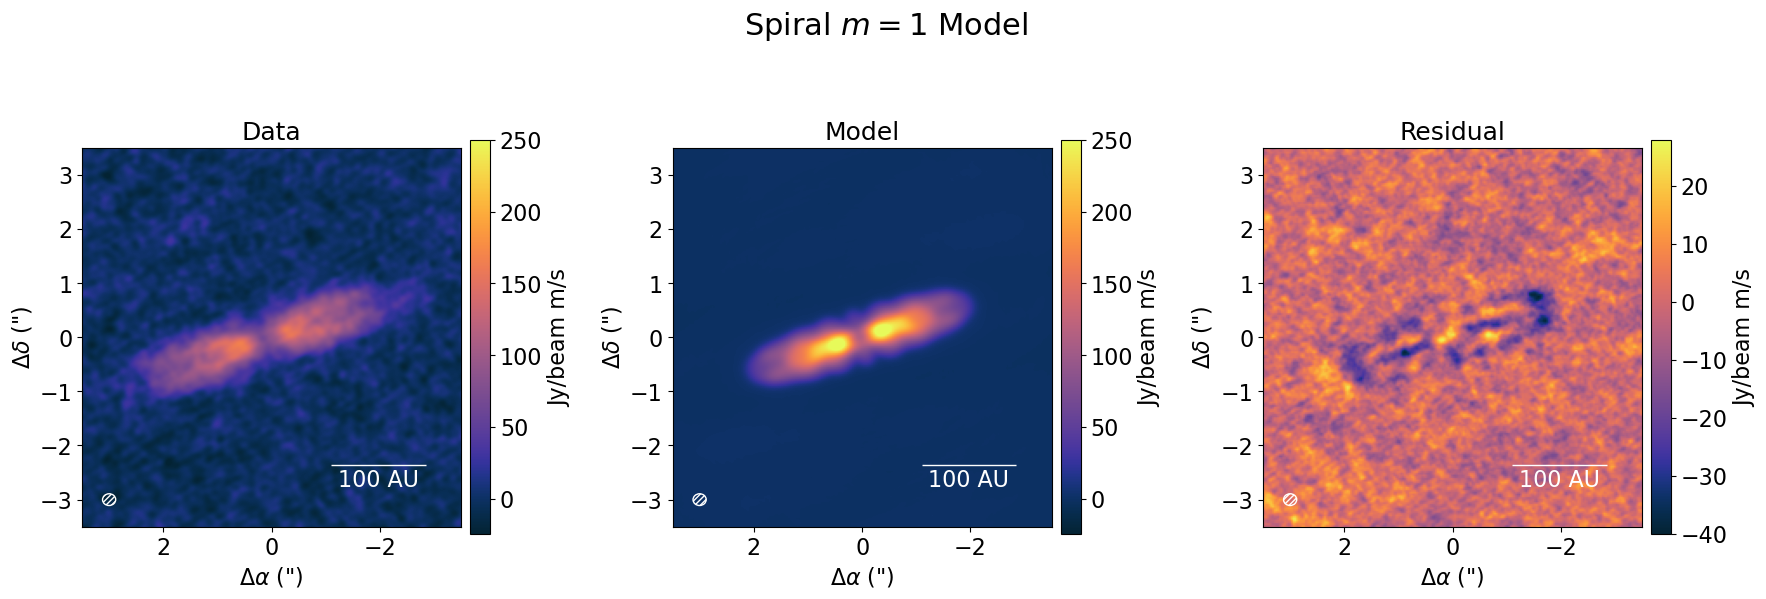

In [27]:

# Load images and WCS (reuse from earlier cells if possible)
data_fits  = fits.open('12CO_LSRK_cleanimage_M0.fits')
model_fits = fits.open('49Ceti_model_spiralm1_4-18_M0.fits')
resid_fits = fits.open('49Ceti_resid_spiralm1_4-18_M0.fits')

data_image  = data_fits['PRIMARY'].data
model_image = model_fits['PRIMARY'].data
resid_image = resid_fits['PRIMARY'].data

wcs = WCS(data_fits['PRIMARY'].header)  # Use data WCS for all (assuming shared)
header = data_fits['PRIMARY'].header

# Compute extent using the 2-arg function (from Cell 6)
extent_data = wcs_extent(data_image, wcs)
# Note: Using extent_data for all to keep offsets consistent; adjust if needed

# Beam parameters from header (in degrees)
bmaj_deg = header['BMAJ']  # Major axis
bmin_deg = header['BMIN']  # Minor axis
bpa_deg  = header['BPA']   # Position angle

# Convert to arcseconds (for plotting in offset coords)
bmaj_arcsec = bmaj_deg * 3600.0
bmin_arcsec = bmin_deg * 3600.0
bpa_arcsec  = bpa_deg  # Angle remains the same

# Plot 3 panels
fig = plt.figure(figsize=(18, 6))
fig.suptitle(r"Spiral $m=1$ Model", fontsize=22, y=1)
gs = gridspec.GridSpec(nrows=1, ncols=3, figure=fig)

panels = [
    (data_image, 'Data', -25, 250),
    (model_image, 'Model', -25, 250),
    (resid_image, 'Residual', None, None),  # Auto-scale for residuals
]

for i, (img, title, vmin, vmax) in enumerate(panels):
    ax = fig.add_subplot(gs[0, i])
    ax.set_aspect('equal')
    im = plt.imshow(img, cmap=cmocean.cm.thermal, origin="lower", extent=extent_data, vmin=vmin, vmax=vmax)
    ax.set_xlim(3.5, -3.5)
    ax.set_ylim(-3.5, 3.5)
    cbar = plt.colorbar(im, ax=ax, shrink=0.8, pad=0.02, label="Jy/beam m/s")
    plt.title(title, fontsize=18)
    ax.set_xlabel(r'$\Delta \alpha$ (")')
    ax.set_ylabel(r'$\Delta \delta$ (")')
    
    # Add beam as ellipse patch (centered at 0,0 offsets)
    beam = Ellipse((3, -3), width=bmin_arcsec, height=bmaj_arcsec, angle=bpa_arcsec,
                   fill=False, hatch='//////', color="white", linewidth=1)
    ax.add_patch(beam)
    # Scalebar: 100 AU at 52 pc ≈ 1.92 arcsec


    distance_pc = dist
    physical_size_au = 100
    distance_au = distance_pc * 206265  # 1 pc = 206265 AU
    theta_arcsec = (physical_size_au / distance_au) * 206265
    scalebar = AnchoredSizeBar(ax.transData, theta_arcsec, f'{physical_size_au} AU', 
                            loc='lower right', pad=1.5, color='white', frameon=False, 
                            size_vertical=0.01)  # Thin bar
    ax.add_artist(scalebar)

plt.tight_layout()
plt.savefig("m1_dmr.pdf")
plt.show()


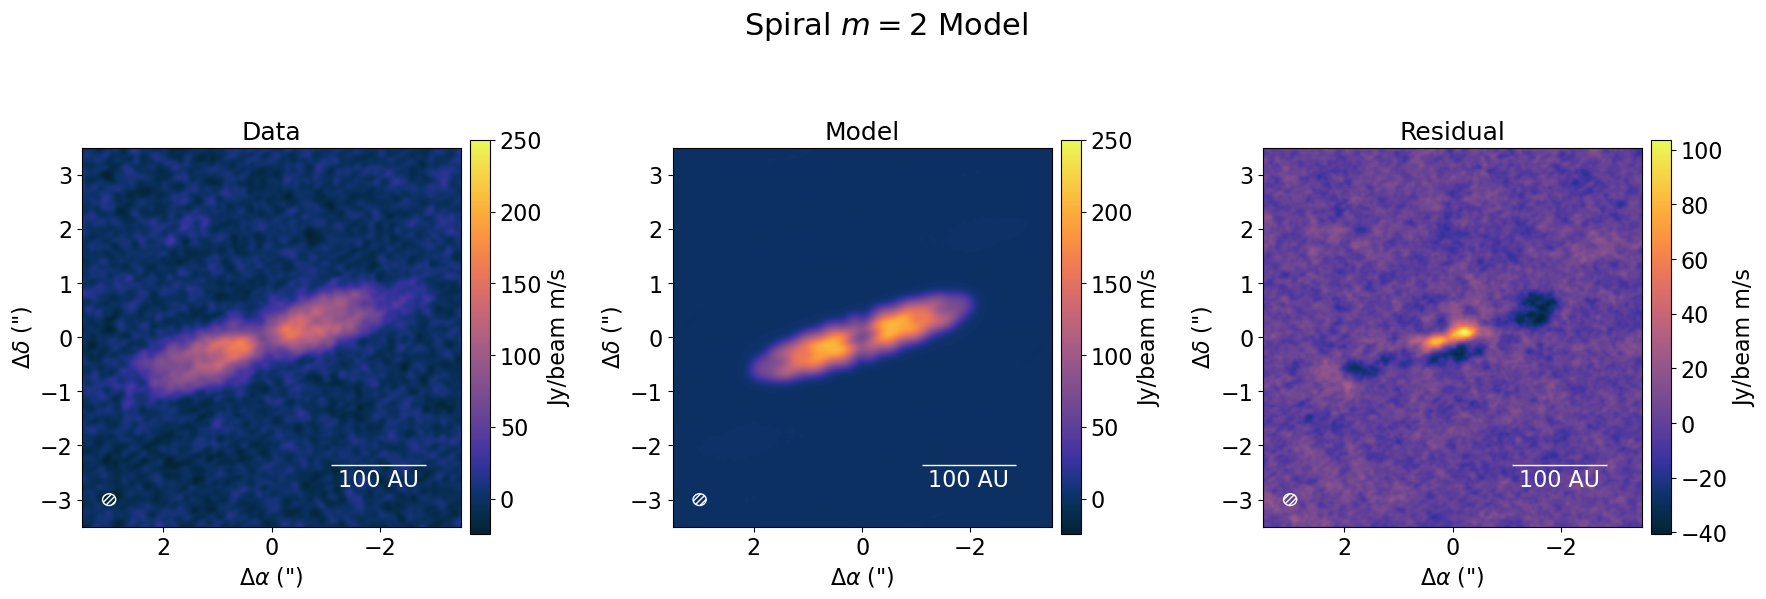

In [28]:

# Load images and WCS (reuse from earlier cells if possible)
data_fits  = fits.open('12CO_LSRK_cleanimage_M0.fits')
model_fits = fits.open('49Ceti_model_spiralm2_4-18_M0.fits')
resid_fits = fits.open('49Ceti_resid_spiral_m2_4-18_M0.fits')

data_image  = data_fits['PRIMARY'].data
model_image = model_fits['PRIMARY'].data
resid_image = resid_fits['PRIMARY'].data

wcs = WCS(data_fits['PRIMARY'].header)  # Use data WCS for all (assuming shared)
header = data_fits['PRIMARY'].header

# Compute extent using the 2-arg function (from Cell 6)
extent_data = wcs_extent(data_image, wcs)
# Note: Using extent_data for all to keep offsets consistent; adjust if needed

# Beam parameters from header (in degrees)
bmaj_deg = header['BMAJ']  # Major axis
bmin_deg = header['BMIN']  # Minor axis
bpa_deg  = header['BPA']   # Position angle

# Convert to arcseconds (for plotting in offset coords)
bmaj_arcsec = bmaj_deg * 3600.0
bmin_arcsec = bmin_deg * 3600.0
bpa_arcsec  = bpa_deg  # Angle remains the same

# Plot 3 panels
fig = plt.figure(figsize=(18, 6))
fig.suptitle(r"Spiral $m=2$ Model", fontsize=22, y=1)
gs = gridspec.GridSpec(nrows=1, ncols=3, figure=fig)

panels = [
    (data_image, 'Data', -25, 250),
    (model_image, 'Model', -25, 250),
    (resid_image, 'Residual', None, None),  # Auto-scale for residuals
]

for i, (img, title, vmin, vmax) in enumerate(panels):
    ax = fig.add_subplot(gs[0, i])
    ax.set_aspect('equal')
    im = plt.imshow(img, cmap=cmocean.cm.thermal, origin="lower", extent=extent_data, vmin=vmin, vmax=vmax)
    ax.set_xlim(3.5, -3.5)
    ax.set_ylim(-3.5, 3.5)
    cbar = plt.colorbar(im, ax=ax, shrink=0.8, pad=0.02, label="Jy/beam m/s")
    plt.title(title, fontsize=18)
    ax.set_xlabel(r'$\Delta \alpha$ (")')
    ax.set_ylabel(r'$\Delta \delta$ (")')
    
    # Add beam as ellipse patch (centered at 0,0 offsets)
    beam = Ellipse((3, -3), width=bmin_arcsec, height=bmaj_arcsec, angle=bpa_arcsec,
                   fill=False, hatch='//////', color="white", linewidth=1)
    ax.add_patch(beam)
    # Scalebar: 100 AU at 52 pc ≈ 1.92 arcsec


    distance_pc = dist
    physical_size_au = 100
    distance_au = distance_pc * 206265  # 1 pc = 206265 AU
    theta_arcsec = (physical_size_au / distance_au) * 206265
    scalebar = AnchoredSizeBar(ax.transData, theta_arcsec, f'{physical_size_au} AU', 
                            loc='lower right', pad=1.5, color='white', frameon=False, 
                            size_vertical=0.01)  # Thin bar
    ax.add_artist(scalebar)

plt.tight_layout()
plt.savefig("m2_dmr.pdf")
plt.show()
